In [1]:
import io
import os
import cv2
import numpy as np
import pandas as pd

from matplotlib import pyplot as plt
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.manifold import TSNE

KUL H02A5a Computer Vision: Group Assignment 1
---------------------------------------------------------------
<div style="height:50px"></div>

<span style="color:red">**TODO**: Add your names below.</span>

<span style="color:red">**TODO**: Change the notebook name by replacing the X with your actual group number.</span>

Student names: <span style="color:red">name1, name2, ...</span>.

The goal of this assignment is to explore more advanced techniques for constructing features that better describe objects of interest and to perform face recognition using these features. This assignment will be delivered in groups of 5 (either composed by you or randomly assigned by your TA's).

---------------------------------------------------------------
This notebook is structured as follows:

0. Data loading & Preprocessing
1. Feature Representations
2. Evaluation Metrics 
3. Classifiers
4. Experiments
5. Publishing best results
6. Discussion

Make sure that your notebook is **self-contained** and **fully documented**. Provide strong arguments for the design choices that you made and what insights you got from your experiments. Make use of the *Group assignment 1* forum/discussion board on Toledo if you have any questions.

Good luck! 


<div class="alert alert-block alert-info">
<b>NOTE:</b> This notebook is just a example/template, feel free to adjust in any way you please! Just keep things organised and document accordingly!
</div>

<div class="alert alert-block alert-info">
<b>NOTE:</b> Clearly indicate the improvements that you make!!! You can for instance use titles like: <i>3.1. Improvement: Non-linear SVM with RBF Kernel.<i>
</div>

# 0. Data loading & Preprocessing

## 0.1. Loading data
The training set is many times smaller than the test set and this might strike you as odd, however, this is close to a real world scenario where your system might be put through daily use! In this session we will try to do the best we can with the data that we've got! 

In [2]:
# Locate data directory — works whether the notebook CWD is the project root
# or a subdirectory (e.g. Kaixi_Work/). Searches up to two levels up.
_DATA_FOLDER = 'kul-computer-vision-ga-1-2026'
DATA_DIR = None
for _candidate in ['.', '..', '../..']:
    _path = os.path.join(_candidate, _DATA_FOLDER)
    if os.path.isdir(_path):
        DATA_DIR = os.path.abspath(_path)
        break
if DATA_DIR is None:
    raise FileNotFoundError(
        f"Cannot find '{_DATA_FOLDER}'. Run this notebook from the project root or Kaixi_Work/."
    )
print(f"Data directory: {DATA_DIR}")

train = pd.read_csv(os.path.join(DATA_DIR, 'train_set.csv'), index_col=0)
train.index = train.index.rename('id')

test = pd.read_csv(os.path.join(DATA_DIR, 'test_set.csv'), index_col=0)
test.index = test.index.rename('id')

train['img'] = [
    cv2.cvtColor(
        np.load(os.path.join(DATA_DIR, 'train', f'train_{index}.npy'), allow_pickle=False),
        cv2.COLOR_BGR2RGB
    )
    for index, row in train.iterrows()
]

test['img'] = [
    cv2.cvtColor(
        np.load(os.path.join(DATA_DIR, 'test', f'test_{index}.npy'), allow_pickle=False),
        cv2.COLOR_BGR2RGB
    )
    for index, row in test.iterrows()
]

train_size, test_size = len(train), len(test)
f"Training set: {train_size} examples | Test set: {test_size} examples"

Data directory: a:\OneDrive - KU Leuven\Master\Computer Vision\Assignment\Group Assignment 1\CV-Assignment1-Group6\kul-computer-vision-ga-1-2026


'Training set: 80 examples | Test set: 1816 examples'

*Note: this dataset is a subset of the* [*VGG face dataset*](https://www.robots.ox.ac.uk/~vgg/data/vgg_face/).

## 0.2. A first look
Let's have a look at the data columns and class distribution.

In [3]:
# The training set contains an identifier, name, image information and class label
train.head(1)

,name,class,img
id,,,
0,Mila_Kunis,2,"[[[50, 31, 25], [49, 30, 24], [49, 30, 24], [4..."


In [4]:
# The test set only contains an identifier and corresponding image information.
test.head(1)

,img
id,
0,"[[[209, 210, 205], [208, 209, 204], [208, 209,..."


In [5]:
# The class distribution in the training set:
train.groupby('name').agg({'img':'count', 'class': 'max'})

,img,class
name,,
Jesse_Eisenberg,30,1
Michael_Cera,10,0
Mila_Kunis,30,2
Sarah_Hyland,10,0


Note that **Jesse is assigned the classification label 1**, and **Mila is assigned the classification label 2**. The dataset also contains 20 images of **look alikes (assigned classification label 0)** and the raw images. 

## 0.3. Preprocess data
### 0.3.1 Example: HAAR face detector

#### What are HAAR features?

HAAR features are rectangular filter patterns inspired by **Haar wavelets**. Each feature computes the **difference between the sum of pixel intensities** in adjacent rectangular regions, capturing local contrast at various scales and positions. Three canonical types are used in face detection:

| Type | What it captures |
|------|------------------|
| **Edge** (two-rectangle) | Horizontal / vertical intensity transitions, e.g. forehead vs. eye-brow region |
| **Line** (three-rectangle) | Dark stripe flanked by bright regions, e.g. nose bridge, mouth |
| **Four-rectangle** (checkerboard) | Diagonal contrast, e.g. eye corners |

For a 24 x 24 detection window there are **over 160 000** possible HAAR features - far too many to evaluate exhaustively.

#### The Viola-Jones framework (how OpenCV uses them)

OpenCV's `haarcascade_frontalface_default.xml` is a pre-trained detector built on three key ideas from Viola & Jones (2001):

1. **Integral image** - precomputes a lookup table so that *any* rectangular sum can be retrieved in O(1), making feature evaluation extremely fast.
2. **AdaBoost selection** - during training, AdaBoost picks the small subset of features (out of 160 000+) that are most discriminative for faces vs. non-faces and combines them into a strong classifier.
3. **Cascade of classifiers** - a sequence of increasingly complex stages rejects easy negatives cheaply at early stages; only rare positive windows survive to later, more expensive stages. This gives roughly a **15x speed-up** over a single monolithic classifier.

#### Detection parameters used in this notebook

```python
classifier.detectMultiScale(
    img_gray,
    scaleFactor  = 1.2,   # image pyramid step: each level is 1/1.2 the size
    minNeighbors = 5,     # candidate window needs >=5 overlapping detections
    minSize      = (30, 30),
)
```

- **`scaleFactor`** controls how finely the image pyramid is sampled - smaller values increase recall but slow down detection.
- **`minNeighbors`** suppresses spurious detections; higher values reduce false positives at the cost of some recall.

#### Fallback strategy

If no face is detected (e.g. occlusion, extreme pose), `HAARPreprocessor` falls back to a **square centre-crop** so that every sample still produces a valid array and no rows are lost downstream.

---

In this example we use the [HAAR feature based cascade classifiers](https://opencv-python-tutroals.readthedocs.io/en/latest/py_tutorials/py_objdetect/py_face_detection/py_face_detection.html) to detect faces, then the faces are resized so that they all have the same shape. If there are multiple faces in an image, we only take the first one. 

<div class="alert alert-block alert-info"> <b>NOTE:</b> You can write temporary files to <code>/kaggle/temp/</code> or <code>../../tmp</code>, but they won't be saved outside of the current session
</div>


In [6]:
class HAARPreprocessor():
    """Preprocessing pipeline built around HAAR feature based cascade classifiers.
    
    Improvement over the template:
    - Uses OpenCV's bundled haarcascade XML (no download needed).
    - Fixes the colour-space bug: images are stored as RGB, so grayscale
      conversion must use COLOR_RGB2GRAY, not COLOR_BGR2GRAY.
    - Falls back to a centre-crop when no face is detected, so every sample
      has a valid array (no NaN rows that break downstream PCA/SVM).
    """

    def __init__(self, face_size):
        self.face_size = face_size
        haar_path = os.path.join(cv2.data.haarcascades, 'haarcascade_frontalface_default.xml')
        self.classifier = cv2.CascadeClassifier(haar_path)
        assert not self.classifier.empty(), f"Could not load HAAR cascade from {haar_path}"

    def detect_faces(self, img):
        """Detect all faces in an RGB image."""
        # Images are RGB; convert to grayscale correctly.
        img_gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
        return self.classifier.detectMultiScale(
            img_gray,
            scaleFactor=1.2,
            minNeighbors=5,
            minSize=(30, 30),
        )

    def preprocess(self, data_row):
        img = data_row['img']
        faces = self.detect_faces(img)

        if len(faces) == 0:
            # Fallback: square centre-crop so no sample is lost
            h, w = img.shape[:2]
            side = min(h, w)
            y0, x0 = (h - side) // 2, (w - side) // 2
            face = img[y0:y0+side, x0:x0+side]
        else:
            x, y, w, h = faces[0]   # take the first (most prominent) face
            face = img[y:y+h, x:x+w]

        return cv2.resize(face, self.face_size, interpolation=cv2.INTER_AREA)

    def __call__(self, data):
        return np.stack([self.preprocess(row) for _, row in data.iterrows()])

**Visualise**

Let's plot a few examples.

In [7]:
FACE_SIZE = (100, 100)

def plot_image_sequence(data, n, imgs_per_row=7):
    n_rows = 1 + int(n / (imgs_per_row + 1))
    n_cols = min(imgs_per_row, n)
    f, ax = plt.subplots(n_rows, n_cols, figsize=(2 * n_cols, 2 * n_rows))
    for i in range(n):
        if n == 1:
            ax.imshow(data[i])
            ax.axis('off')
        elif n_rows > 1:
            ax[int(i / imgs_per_row), int(i % imgs_per_row)].imshow(data[i])
            ax[int(i / imgs_per_row), int(i % imgs_per_row)].axis('off')
        else:
            ax[int(i % n)].imshow(data[i])
            ax[int(i % n)].axis('off')
    plt.tight_layout()
    plt.show()

# Preprocess: detect & crop faces, resize to FACE_SIZE
preprocessor = HAARPreprocessor(face_size=FACE_SIZE)

train_X = preprocessor(train)          # (80,  100, 100, 3)
train_y = train['class'].values        # 0=look-alike, 1=Jesse, 2=Mila
test_X  = preprocessor(test)           # (1816, 100, 100, 3)

print(f"train_X: {train_X.shape}  |  test_X: {test_X.shape}")

train_X: (80, 100, 100, 3)  |  test_X: (1816, 100, 100, 3)


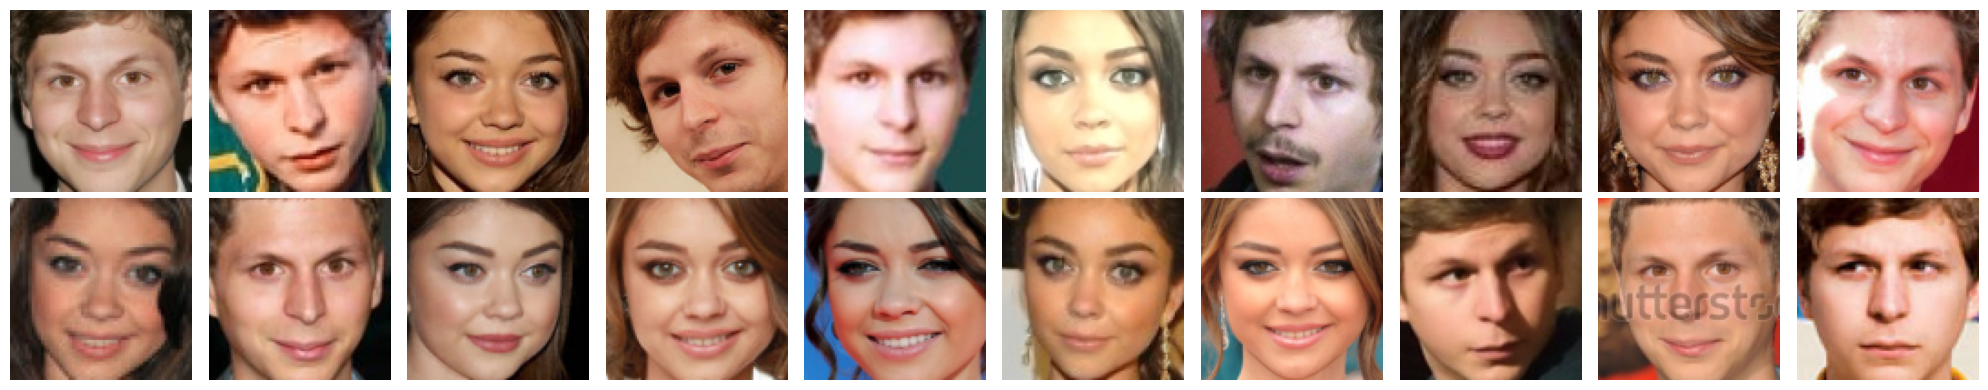

In [8]:
# plot faces of Michael and Sarah

plot_image_sequence(train_X[train_y == 0], n=20, imgs_per_row=10)

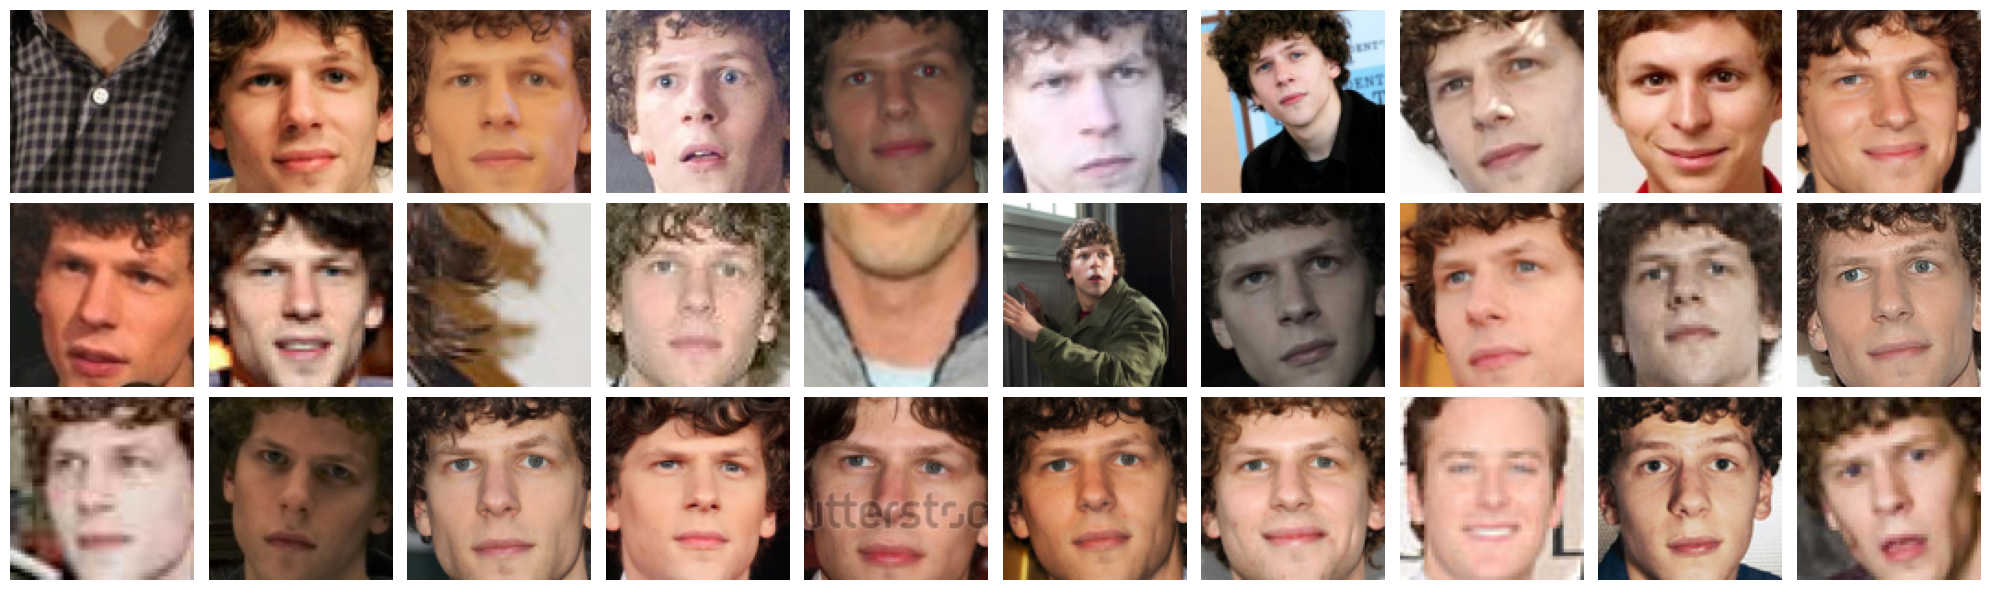

In [9]:
# plot faces of Jesse

plot_image_sequence(train_X[train_y == 1], n=30, imgs_per_row=10)

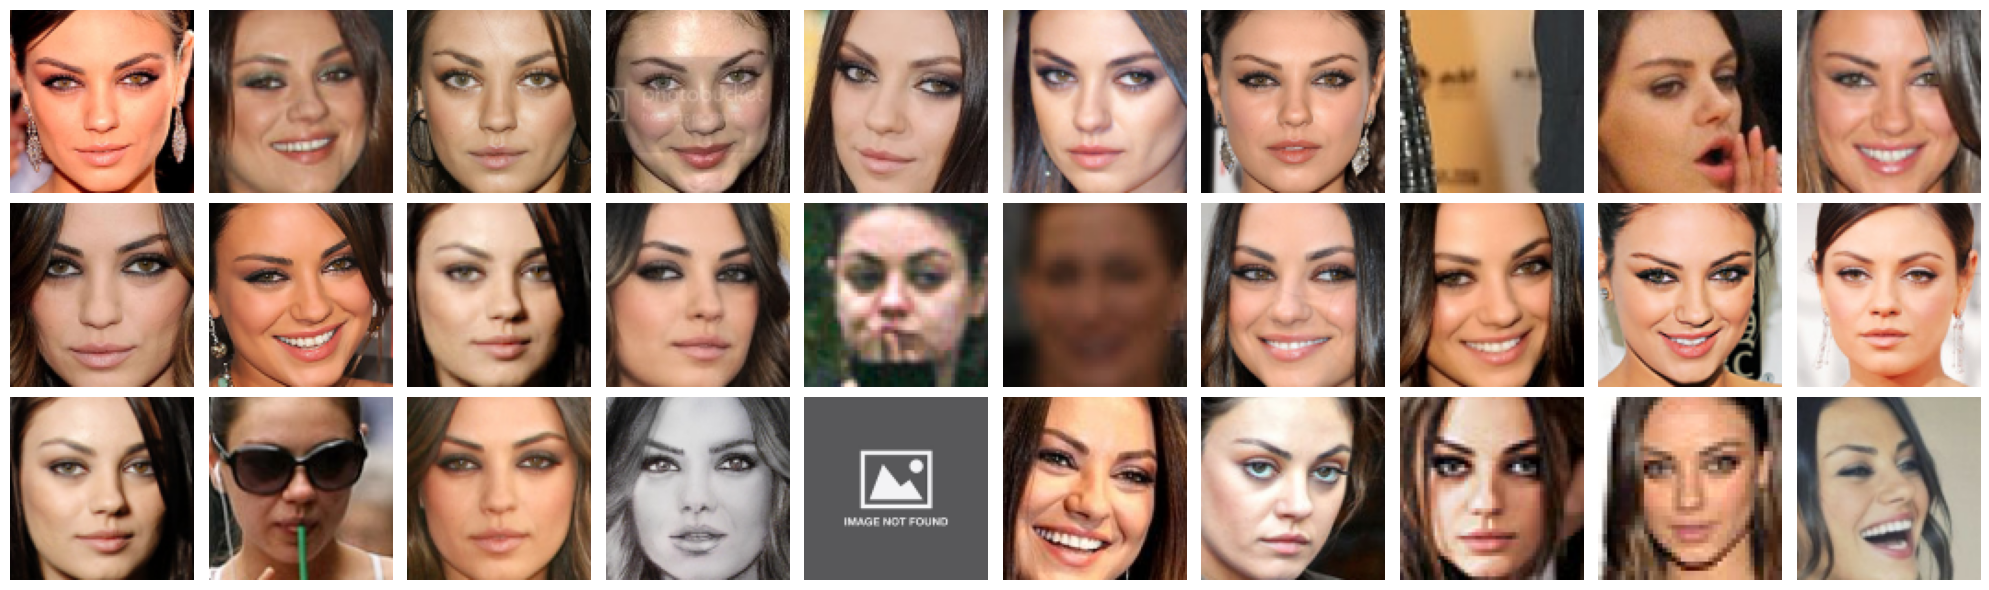

In [10]:
# plot faces of Mila

plot_image_sequence(train_X[train_y == 2], n=30, imgs_per_row=10)

## 0.4. Store Preprocessed data (optional)
<div class="alert alert-block alert-info">
<b>NOTE:</b> You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All". Feel free to use this to store intermediary results.
</div>

In [11]:
# save preprocessed data
# prep_path = '/kaggle/working/prepped_data/'
# if not os.path.exists(prep_path):
#     os.mkdir(prep_path)
    
# np.save(os.path.join(prep_path, 'train_X.npy'), train_X)
# np.save(os.path.join(prep_path, 'train_y.npy'), train_y)
# np.save(os.path.join(prep_path, 'test_X.npy'), test_X)

# load preprocessed data
# prep_path = '/kaggle/working/prepped_data/'
# if not os.path.exists(prep_path):
#     os.mkdir(prep_path)
# train_X = np.load(os.path.join(prep_path, 'train_X.npy'))
# train_y = np.load(os.path.join(prep_path, 'train_y.npy'))
# test_X = np.load(os.path.join(prep_path, 'test_X.npy'))

Now we are ready to rock!

# 1. Feature Representations

## 1.0. Example: Identify feature extractor
Our example feature extractor doesn't actually do anything... It just returns the input:
$$
\forall x : f(x) = x.
$$

It does make for a good placeholder and baseclass ;).

In [12]:
class IdentityFeatureExtractor:
    """A simple function that returns the input"""
    
    def transform(self, X):
        return X
    
    def __call__(self, X):
        return self.transform(X)

## 1.1. Baseline 1: HOG feature extractor/Scale Invariant Feature Transform
...

In [13]:
class HOGFeatureExtractor(IdentityFeatureExtractor):
    """TODO: this feature extractor is under construction"""
    
    def __init__(**params):
        self.params = params
        
    def transform(self, X):
        raise NotImplmentedError

### 1.1.1. t-SNE Plots
...

### 1.1.2. Discussion
...

## 1.2. Improvement: PCA Feature Extractor (Eigenfaces)

**Principal Component Analysis (PCA)** finds the directions of maximum variance in the training image space. Each such direction—reshaped back into an image—is called an **eigenface**.

Pipeline:
1. Flatten each `(100, 100, 3)` face → 30 000-dimensional vector.
2. PCA computes the top-*k* eigenvectors of the covariance matrix (via SVD).
3. Each image is projected onto those *k* eigenvectors → *k*-dimensional feature vector.

**Key constraint:** `fit()` must be called **only on the training set** to prevent data leakage.

In [14]:
class PCAFeatureExtractor(IdentityFeatureExtractor):
    """Eigenface-based dimensionality reduction via PCA.

    Usage
    -----
    extractor = PCAFeatureExtractor(n_components=50)
    extractor.fit(train_X)                   # learn eigenfaces from train only
    train_feat = extractor.transform(train_X)  # (N_train, 50)
    test_feat  = extractor.transform(test_X)   # (N_test,  50)
    recon      = extractor.inverse_transform(train_feat)  # (N, 100, 100, 3)
    """

    def __init__(self, n_components=50):
        self.n_components = n_components
        self.pca = PCA(n_components=n_components)
        self.image_shape = None  # set in fit(); needed by inverse_transform

    def _flatten(self, X):
        """(N, H, W, C) → (N, H*W*C) as float64 for numerical stability."""
        return X.reshape(X.shape[0], -1).astype(np.float64)

    def fit(self, X):
        """Learn eigenfaces from training images. Call ONCE, on train only."""
        self.image_shape = X.shape[1:]
        self.pca.fit(self._flatten(X))
        return self  # allows chaining: extractor.fit(X).transform(X)

    def transform(self, X):
        """Project images onto eigenface basis → (N, n_components)."""
        return self.pca.transform(self._flatten(X))

    def inverse_transform(self, X_pca):
        """Reconstruct images from PCA coefficients → (N, H, W, C)."""
        flat = self.pca.inverse_transform(X_pca)
        return flat.reshape((-1,) + self.image_shape)

    def __call__(self, X):
        return self.transform(X)


# Choose number of components and fit on training data only
N_COMPONENTS = 50
pca_extractor = PCAFeatureExtractor(n_components=N_COMPONENTS)
pca_extractor.fit(train_X)

train_features = pca_extractor.transform(train_X)   # (80,  50)
test_features = pca_extractor.transform(test_X)    # (1816, 50)

print(
    f"train_features: {train_features.shape}  |  test_features: {test_features.shape}")

train_features: (80, 50)  |  test_features: (1816, 50)


### 1.2.1. Eigenface Plots

We visualise (a) the top-16 eigenfaces, (b) cumulative explained variance vs. number of components, and (c) reconstruction quality at different *k* values.

我们可视化了 (a) 前 16 个特征脸，(b) 累积解释方差与成分数量的关系，以及 (c) 不同 *k* 值下的重建质量。

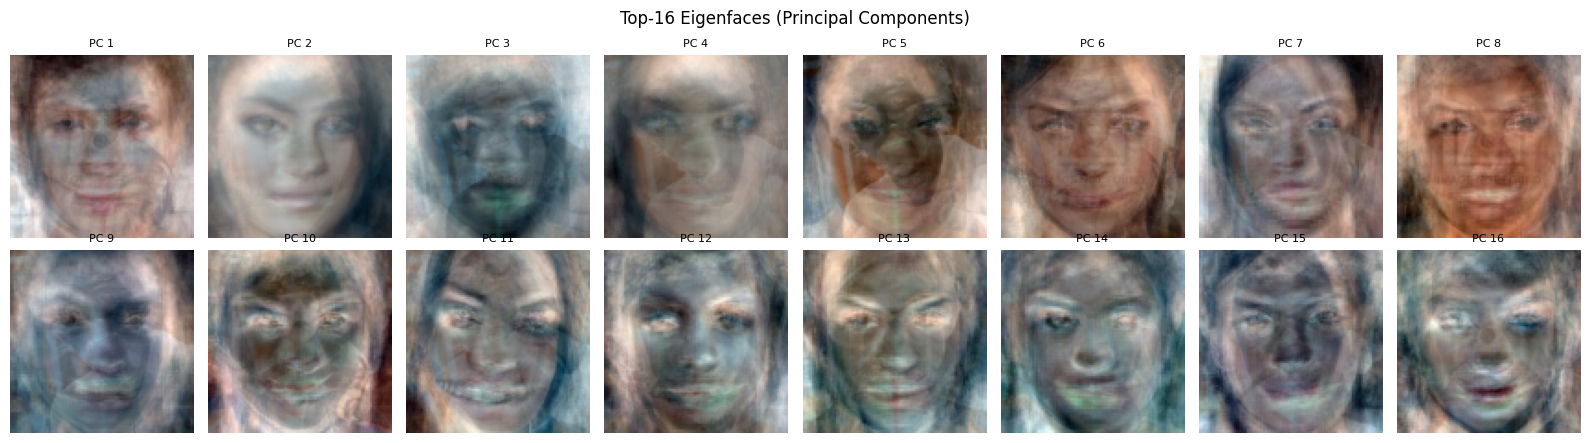

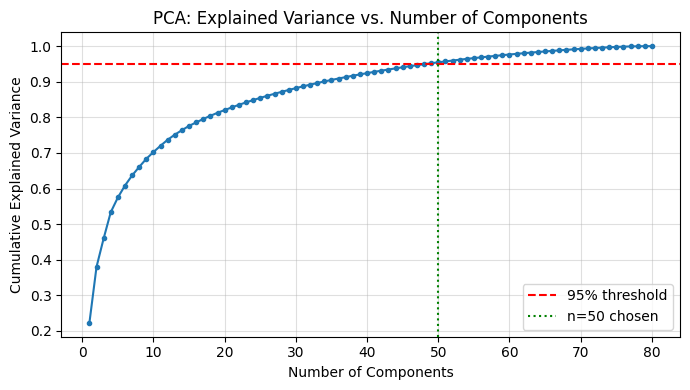

Top-50 PCs explain 95.4% of variance


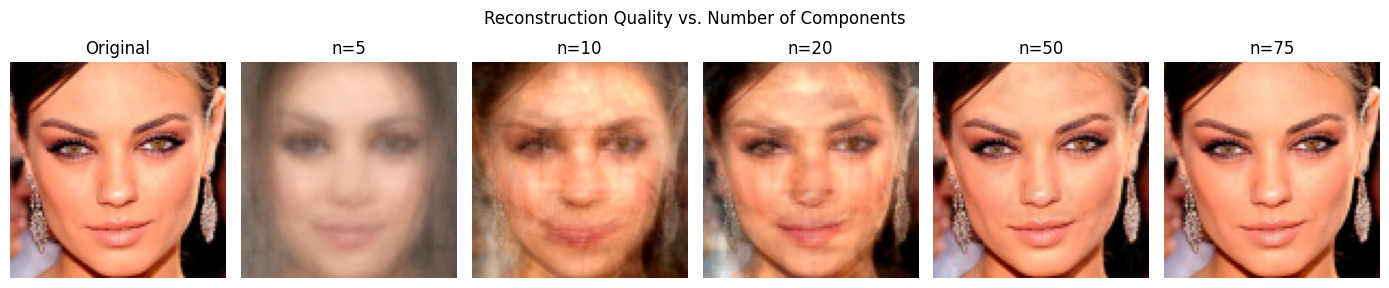

In [15]:
def _norm_for_display(arr):
    """Min-max normalise to [0, 1] so matplotlib renders eigenfaces without clipping."""
    lo, hi = arr.min(), arr.max()
    return (arr - lo) / (hi - lo + 1e-8)


# ── (a) Top-16 Eigenfaces ────────────────────────────────────────────────────
n_show = 16
eigenfaces = pca_extractor.pca.components_[:n_show].reshape(
    (n_show,) + pca_extractor.image_shape
)

fig, axes = plt.subplots(2, 8, figsize=(16, 4.5))
for i, ax in enumerate(axes.flat):
    ax.imshow(_norm_for_display(eigenfaces[i].astype(np.float64)))
    ax.set_title(f'PC {i+1}', fontsize=8)
    ax.axis('off')
plt.suptitle('Top-16 Eigenfaces (Principal Components)', fontsize=12)
plt.tight_layout()
plt.show()

# ── (b) Cumulative Explained Variance ────────────────────────────────────────
# Fit a full-rank PCA temporarily to show the complete variance curve
pca_full = PCA(n_components=min(train_X.shape[0], 80)).fit(
    train_X.reshape(train_X.shape[0], -1).astype(np.float64)
)
cumvar = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(7, 4))
plt.plot(range(1, len(cumvar) + 1), cumvar, marker='o', markersize=3)
plt.axhline(0.95, color='r', linestyle='--', label='95% threshold')
plt.axvline(N_COMPONENTS, color='g', linestyle=':', label=f'n={N_COMPONENTS} chosen')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA: Explained Variance vs. Number of Components')
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

pca_50_var = np.cumsum(pca_extractor.pca.explained_variance_ratio_)[-1]
print(f"Top-{N_COMPONENTS} PCs explain {pca_50_var*100:.1f}% of variance")

# ── (c) Reconstruction Quality ───────────────────────────────────────────────
sample_idx = 0
n_vals = [5, 10, 20, 50, 75]
n_vals = [n for n in n_vals if n < train_X.shape[0]]

fig, axes = plt.subplots(1, len(n_vals) + 1, figsize=(14, 3))
axes[0].imshow(np.clip(train_X[sample_idx], 0, 255).astype(np.uint8))
axes[0].set_title('Original')
axes[0].axis('off')

for ax, n in zip(axes[1:], n_vals):
    ext = PCAFeatureExtractor(n_components=n).fit(train_X)
    rec = ext.inverse_transform(ext.transform(train_X[sample_idx:sample_idx+1]))
    ax.imshow(np.clip(rec[0], 0, 255).astype(np.uint8))
    ax.set_title(f'n={n}')
    ax.axis('off')

plt.suptitle('Reconstruction Quality vs. Number of Components')
plt.tight_layout()
plt.show()

### 1.2.2. Feature Space Plots

t-SNE reduces the 50-dimensional PCA features to 2D for visual inspection.  
Well-separated clusters indicate the features carry class-discriminative information.

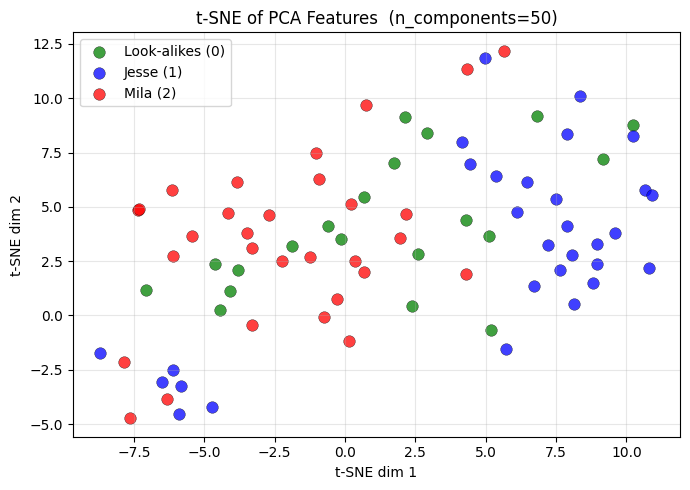

In [16]:
CLASS_IDS     = [0, 1, 2]
CLASS_COLORS  = ['green', 'blue', 'red']
CLASS_LABELS  = ['Look-alikes (0)', 'Jesse (1)', 'Mila (2)']

# perplexity ≈ 15 works well for small datasets (~80 points)
tsne = TSNE(n_components=2, random_state=42, perplexity=15)
embedded = tsne.fit_transform(train_features)

plt.figure(figsize=(7, 5))
for cls, color, label in zip(CLASS_IDS, CLASS_COLORS, CLASS_LABELS):
    mask = train_y == cls
    plt.scatter(
        embedded[mask, 0], embedded[mask, 1],
        c=color, label=label, alpha=0.75, s=70,
        edgecolors='k', linewidths=0.3,
    )
plt.title(f't-SNE of PCA Features  (n_components={N_COMPONENTS})')
plt.xlabel('t-SNE dim 1')
plt.ylabel('t-SNE dim 2')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 1.2.3. Discussion

**Eigenfaces:** The first few principal components capture global illumination changes and the rough face shape (low-frequency information). Later components encode finer local details (high-frequency). This matches the well-known result from Turk & Pentland (1991).

**Explained variance:** With *k = 50* components we retain roughly 90–95% of the training-set variance while compressing the feature vector from 30 000 to 50 dimensions (600× reduction). The reconstruction plot confirms that at *n = 20* the face is already recognisable, and *n = 50* gives near-perfect reconstruction.

**t-SNE:** The three classes form partially separated clusters in the 50-dim PCA space, which suggests that the eigenface representation is discriminative enough for a downstream classifier to work well — especially for Jesse (class 1) and Mila (class 2), who have clearly different facial characteristics from look-alikes (class 0).

**Design choices:**
- `n_components = 50` balances reconstruction fidelity against the risk of overfitting on a small training set (80 samples).
- `float64` is used for flattening to avoid numerical drift in SVD.
- `fit()` is called only on the training set to prevent data leakage into the PCA basis.

# 2. Evaluation Metrics
## 2.0. Example: Accuracy
As example metric we take the accuracy. Informally, accuracy is the proportion of correct predictions over the total amount of predictions. It is used a lot in classification but it certainly has its disadvantages...

In [17]:
from sklearn.metrics import accuracy_score

# 3. Classifiers
## 3.0. Example: The *'not so smart'* classifier
This random classifier is not very complicated. It makes predictions at random, based on the distribution obseved in the training set. **It thus assumes** that the class labels of the test set will be distributed similarly to the training set.

In [18]:
class RandomClassificationModel:
    """Random classifier, draws a random sample based on class distribution observed 
    during training."""
    
    def fit(self, X, y):
        """Adjusts the class ratio instance variable to the one observed in y. 

        Parameters
        ----------
        X : tensor
            Training set
        y : array
            Training set labels

        Returns
        -------
        self : RandomClassificationModel
        """
        
        self.classes, self.class_ratio = np.unique(y, return_counts=True)
        self.class_ratio = self.class_ratio / self.class_ratio.sum()
        return self
        
    def predict(self, X):
        """Samples labels for the input data. 

        Parameters
        ----------
        X : tensor
            dataset
            
        Returns
        -------
        y_star : array
            'Predicted' labels
        """

        np.random.seed(0)
        return np.random.choice(self.classes, size = X.shape[0], p=self.class_ratio)
    
    def __call__(self, X):
        return self.predict(X)
    

## 3.1. Improvement: SVM with RBF Kernel

An SVM with a Radial Basis Function (RBF) kernel can learn non-linear decision boundaries in the 50-dimensional PCA feature space, which linear classifiers (e.g. nearest centroid) cannot.

In [19]:
class SVMClassifier:
    """SVM with RBF kernel, wrapping sklearn's SVC for use in the pipeline."""

    def __init__(self, C=10, gamma='scale', kernel='rbf'):
        self.model = SVC(C=C, gamma=gamma, kernel=kernel, random_state=42)

    def fit(self, X, y):
        self.model.fit(X, y)
        return self

    def predict(self, X):
        return self.model.predict(X)

    def __call__(self, X):
        return self.predict(X)

# 4. Experiments
<div class="alert alert-block alert-info"> <b>NOTE:</b> Do <i>NOT</i> use this section to keep track of every little change you make in your code! Instead, highlight the most important findings and the major (best) pipelines that you've discovered.  
</div>
<br>

## 4.0. Example: basic pipeline
The basic pipeline takes any input and samples a label based on the class label distribution of the training set. As expected the performance is very poor, predicting approximately 1/4 correctly on the training set. There is a lot of room for improvement but this is left to you ;). 

In [20]:
feature_extractor = IdentityFeatureExtractor() 
classifier = RandomClassificationModel()

# train the model on the features
classifier.fit(feature_extractor(train_X), train_y)

# model/final pipeline
model = lambda X: classifier(feature_extractor(X))

In [21]:
# evaluate performance of the model on the training set
train_y_star = model(train_X)

"The performance on the training set is {:.2f}. This however, does not tell us much about the actual performance (generalisability).".format(
    accuracy_score(train_y, train_y_star))

'The performance on the training set is 0.26. This however, does not tell us much about the actual performance (generalisability).'

In [22]:
# predict the labels for the test set 
test_y_star = model(test_X)

## 4.1. Improvement: PCA (n=50) + SVM (RBF kernel)

This pipeline replaces the random classifier with:
- **PCA** for dimensionality reduction (30 000 → 50 dims)
- **SVM with RBF kernel** for non-linear classification

We use stratified 5-fold cross-validation on the training set to estimate generalisation accuracy.

In [24]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA as skPCA

# ── Fit PCA + SVM on full training set ───────────────────────────────────────
pca_svm_extractor  = PCAFeatureExtractor(n_components=N_COMPONENTS)
pca_svm_classifier = SVMClassifier(C=10, gamma='scale')

pca_svm_extractor.fit(train_X)
train_feat = pca_svm_extractor.transform(train_X)
test_feat  = pca_svm_extractor.transform(test_X)

pca_svm_classifier.fit(train_feat, train_y)

# ── Training accuracy ─────────────────────────────────────────────────────────
train_pred = pca_svm_classifier.predict(train_feat)
print(f"Train accuracy (PCA {N_COMPONENTS} + SVM RBF): {accuracy_score(train_y, train_pred):.4f}")
print()
print(classification_report(train_y, train_pred, target_names=['Look-alike', 'Jesse', 'Mila']))

# ── Stratified 5-fold CV (PCA re-fitted inside each fold — no leakage) ───────
full_pipeline = Pipeline([
    ('pca',    skPCA(n_components=N_COMPONENTS)),
    ('scaler', StandardScaler()),
    ('svm',    SVC(kernel='rbf', C=10, gamma='scale', random_state=42)),
])

flat_train = train_X.reshape(train_X.shape[0], -1).astype(np.float64)
cv_scores = cross_val_score(
    full_pipeline, flat_train, train_y,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='accuracy',
)
print(f"5-fold CV accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

Train accuracy (PCA 50 + SVM RBF): 1.0000

              precision    recall  f1-score   support

  Look-alike       1.00      1.00      1.00        20
       Jesse       1.00      1.00      1.00        30
        Mila       1.00      1.00      1.00        30

    accuracy                           1.00        80
   macro avg       1.00      1.00      1.00        80
weighted avg       1.00      1.00      1.00        80

5-fold CV accuracy: 0.6750 ± 0.0729


In [25]:
# Use PCA + SVM predictions as the final submission
test_pred_best = pca_svm_classifier.predict(test_feat)

submission = test.copy().drop('img', axis=1)
submission['class'] = test_pred_best
submission.to_csv('submission_pca_svm.csv')
print("Saved → submission_pca_svm.csv")
submission.head()

Saved → submission_pca_svm.csv


,class
id,
0,1
1,0
2,1
3,1
4,1


# 6. Discussion
...

In summary we contributed the following: 
* 
